# 分类模型

In [1]:
# 定义一个字典，将数字标签映射为对应的中文名称
classification_names = {
    0: '上身衣服',  # 数字 0 对应“上身衣服”
    1: '鞋',       # 数字 1 对应“鞋”
    2: '包',       # 数字 2 对应“包”
    3: '下身衣服',  # 数字 3 对应“下身衣服”
    4: '手表'      # 数字 4 对应“手表”
}

In [2]:
# 定义数据集加载类
import torch  # 导入 PyTorch 库，用于深度学习任务
from PIL import Image  # 导入 PIL 库中的 Image 模块，用于图像处理
import os  # 导入 os 库，用于文件和目录操作
from torch.utils.data import Dataset  # 导入 PyTorch 的 Dataset 类，用于创建自定义数据集
import torchvision.transforms as T  # 导入 torchvision 的 transforms 模块，用于图像预处理
import pandas as pd  # 导入 pandas 库，用于数据处理和分析

def sorted_alphanumeric(data):
    """按字母数字混合顺序对文件名进行排序（例如：img1, img2, ..., img10）"""
    # 定义转换函数：将数字部分转换为整数，非数字部分转换为小写
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    # 生成排序键：用正则分割字符串，分别处理数字和非数字部分
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    # 按生成的键排序
    return sorted(data, key=alphanum_key)

# 定义自定义数据集类 ImageDataset，继承自 PyTorch 的 Dataset 类
class ImageDataset(Dataset):
    def __init__(self, main_dir, transform=None):
        """
        初始化方法。
        :param main_dir: 图像文件夹的主路径
        :param transform: 图像预处理操作（如缩放、裁剪、归一化等），默认为 None
        """
        self.main_dir = main_dir  # 存储主目录路径
        self.transform = transform  # 存储图像预处理操作
        self.all_imgs = sorted_alphanumeric(os.listdir(main_dir))  # 获取主目录下的所有图像文件名
        # 读取包含分类标签的 CSV 文件
        self.classifications = pd.read_csv('common/fashion-labels.csv')  # 从指定路径加载 CSV 文件到 DataFrame
        # 将数据类型转换为字典，提升查询效率
        self.label_dict = dict(zip(self.classifications['id'], self.classifications['target']))

    def __len__(self):
        """
        返回数据集中图像的数量。
        """
        return len(self.all_imgs)  # 返回图像文件的总数

    def __getitem__(self, idx):
        """
        根据索引 idx 获取图像及其标签。
        :param idx: 图像的索引
        :return: 预处理后的图像张量和对应的标签
        """
        # print("index: ", idx)
        img_loc = os.path.join(self.main_dir, self.all_imgs[idx])  # 获取第 idx 张图像的完整路径
        image = Image.open(img_loc).convert("RGB")  # 打开图像并将其转换为 RGB 格式
        img_flag_id = self.label_dict[idx]  # 在分类数据中查找对应的标签

        # 对图像进行预处理（如果定义了 transform）
        if self.transform is not None:
            tensor_image = self.transform(image)  # 应用预处理操作，将图像转换为张量
        else:
            raise RuntimeError("transform参数不能为None，需指定预处理方法")

        return tensor_image, img_flag_id  # 返回图像张量和标签

In [3]:
import re

# 检查是否有可用的GPU，如果有则使用GPU，否则使用CPU
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# 定义数据预处理流程：将图像调整为64x64大小，并将其转换为Tensor
transforms = T.Compose([T.Resize((64, 64)), T.ToTensor()])

# 打印提示信息，表示正在创建数据集
print("------------ 正在创建数据集 ------------")
# 使用ImageDataset类加载数据集，数据集路径为'./image_similarity/dataset/'，并应用定义好的预处理流程
full_dataset = ImageDataset('common/dataset/', transforms)
# 计算训练集和验证集的大小，训练集占数据集的75%，验证集占剩余的25%
train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size

# 使用random_split函数将数据集随机划分为训练集和验证集
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

# 打印提示信息，表示数据集已创建
print("------------ 数据集创建完成 ------------")

# 打印提示信息，表示正在创建DataLoader
print("------------ 创建数据加载器 ------------")

# 定义批次大小为32
batch = 32

# 创建训练集的DataLoader，批次大小为32，打乱数据顺序，并丢弃最后一个不完整的批次
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch, shuffle=True, drop_last=True
)

# 创建验证集的DataLoader，批次大小为32，不打乱数据顺序
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch
)

# 创建完整数据集的DataLoader，批次大小为32，不打乱数据顺序
full_loader = torch.utils.data.DataLoader(
    full_dataset, batch_size=batch
)

print("------------ 数据加载器创建完成 ------------")

# 遍历训练集的DataLoader，获取第一个批次的数据并打印其形状
for (x, y) in train_loader:
    print(x.shape)  # 打印输入数据的形状
    print(y.shape)  # 打印标签数据的形状
    break  # 获取第一个批次后退出循环

------------ 正在创建数据集 ------------
------------ 数据集创建完成 ------------
------------ 创建数据加载器 ------------
------------ 数据加载器创建完成 ------------
torch.Size([32, 3, 64, 64])
torch.Size([32])


In [4]:
import torch.nn as nn  # 导入 PyTorch 的神经网络模块，用于构建神经网络
import torch.nn.functional as F  # 导入 PyTorch 的函数模块，包含激活函数、损失函数等


class Classifier(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()
        # 定义第一个卷积层，输入通道数为3，输出通道数为8，卷积核大小为3x3，步幅为1，填充为1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        # 使用填充为1的卷积操作，输出特征图的尺寸与输入相同（Same convolutions）

        # 定义最大池化层，池化核大小为2x2，步幅为2
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 定义第二个卷积层，输入通道数为8，输出通道数为16，卷积核大小为3x3，步幅为1，填充为1
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        # 上一层的输出通道数为8，因此这一层的输入通道数为8

        # 定义全连接层，输入大小为16*16*16，输出大小为num_classes（分类数）
        self.fc1 = nn.Linear(16 * 16 * 16, num_classes)
        # 输入大小为16是因为conv2的输出通道数为16，16*16是因为经过两次池化后，特征图的尺寸为16x16

    def forward(self, x):
        # 第一层卷积 + ReLU激活函数
        x = F.relu(self.conv1(x))
        # print("经过第一层卷积和ReLU激活函数后的维度：", x.shape)
        # 池化操作
        x = self.pool(x)
        # print("经过第一层池化后的维度：", x.shape)
        # 第二层卷积 + ReLU激活函数
        x = F.relu(self.conv2(x))
        # print("经过第二层卷积和ReLU激活函数后的维度：", x.shape)
        # 池化操作
        x = self.pool(x)
        # print("经过第二层池化后的维度：", x.shape)
        # 将特征图展平为一维向量，保留batch_size维度，其余维度展平
        x = x.reshape(x.shape[0], -1)
        # print("经过一维展平后的维度：", x.shape)

        # 全连接层
        x = self.fc1(x)
        # print("经过全连接层的维度：", x.shape)

        # 经过log_softmax处理后返回，该函数通常用于多分类任务
        x = F.log_softmax(x, dim=1)
        # print("经过log_softmax处理后的维度：", x.shape)
        return x

# 实例化CNN模型
model = Classifier()
# 打印模型结构
print(model)

# 获取训练数据加载器的迭代器
it = iter(train_loader)
# 获取下一个批次的数据
X_batch, y_batch = next(it)
# 打印模型前向传播输出的形状
print("数据经过模型向前传递后的维度：", model.forward(X_batch).shape)

Classifier(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=5, bias=True)
)
数据经过模型向前传递后的维度： torch.Size([32, 5])


In [5]:
# 指定损失函数为交叉熵损失函数，适用于多分类任务
criterion = nn.CrossEntropyLoss()

# 指定优化器为Adam优化器，优化对象是模型的所有参数，学习率为0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 指定训练的轮数为20
n_epochs = 20

# 将模型移动到指定的设备（GPU或CPU）
model.to(device)

# 开始训练循环，遍历每个epoch
for epoch in range(1, n_epochs + 1):
    # 初始化训练损失为0.0，用于累加每个批次的损失
    train_loss = 0.0

    ###################
    # 训练模型 #
    ###################
    for x, y in train_loader:  # 遍历训练集的每个批次
        # 将输入数据x和标签y移动到指定的设备（GPU或CPU）
        x = x.to(device)
        y = y.to(device)

        # 清除优化器中所有参数的梯度，避免梯度累积
        optimizer.zero_grad()
        # 前向传播：将输入数据x传递给模型，得到输出结果
        output = model(x)
        # 计算损失值，output是模型的预测结果，y是真实标签
        loss = criterion(output, y)
        # 反向传播：计算损失相对于模型参数的梯度
        loss.backward()
        # 更新模型参数：执行一次优化步骤
        optimizer.step()
        # 累加当前批次的损失值，乘以批次大小（x.size(0)）以得到总损失
        train_loss += loss.item() * x.size(0)

    # 计算平均训练损失，总损失除以训练集的批次数量
    train_loss = train_loss / len(train_loader)
    # 打印当前epoch的训练损失
    print("Epoch: {} \tTraining Loss: {:.6f}".format(epoch, train_loss))

Epoch: 1 	Training Loss: 7.041594
Epoch: 2 	Training Loss: 2.320782
Epoch: 3 	Training Loss: 1.787601
Epoch: 4 	Training Loss: 1.489755
Epoch: 5 	Training Loss: 1.337367
Epoch: 6 	Training Loss: 1.172845
Epoch: 7 	Training Loss: 0.974604
Epoch: 8 	Training Loss: 0.880586
Epoch: 9 	Training Loss: 0.671855
Epoch: 10 	Training Loss: 0.601086
Epoch: 11 	Training Loss: 0.547291
Epoch: 12 	Training Loss: 0.485923
Epoch: 13 	Training Loss: 0.448621
Epoch: 14 	Training Loss: 0.372125
Epoch: 15 	Training Loss: 0.316603
Epoch: 16 	Training Loss: 0.298091
Epoch: 17 	Training Loss: 0.192960
Epoch: 18 	Training Loss: 0.162941
Epoch: 19 	Training Loss: 0.166721
Epoch: 20 	Training Loss: 0.225248


(32, 5)
(32, 64, 64, 3)


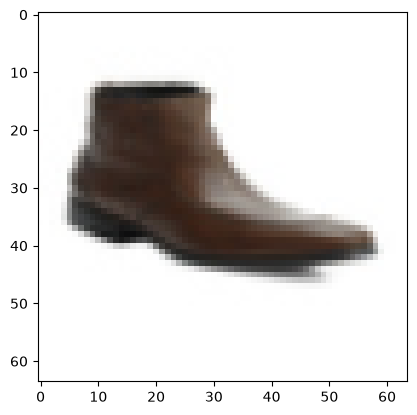

label:  [-42.62168    0.       -47.03417  -36.354366 -45.034683]
label.shape:  (5,)
鞋


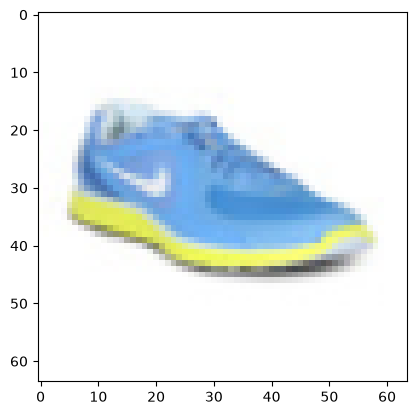

label:  [-32.84707    0.       -19.992916 -27.090788 -27.764431]
label.shape:  (5,)
鞋


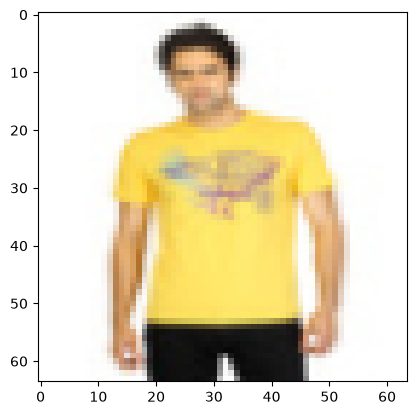

label:  [  0.       -43.711296 -50.57601  -37.933403 -46.336647]
label.shape:  (5,)
上身衣服


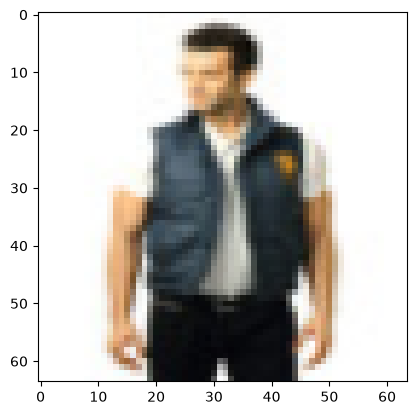

label:  [  0.       -25.64415  -32.7069   -20.606035 -37.42729 ]
label.shape:  (5,)
上身衣服


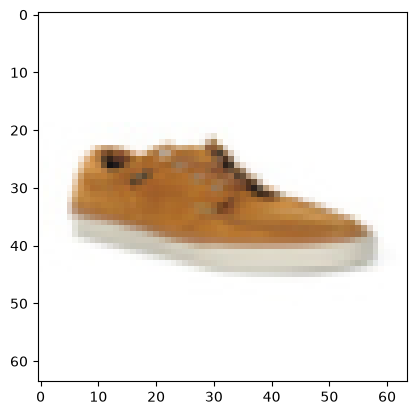

label:  [-27.481352   0.       -20.850441 -37.350784 -31.42234 ]
label.shape:  (5,)
鞋


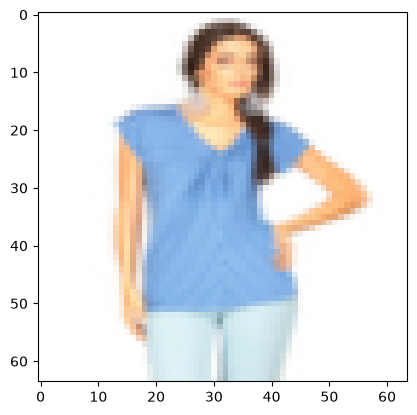

label:  [  0.       -24.85748  -26.518227 -27.260872 -32.71486 ]
label.shape:  (5,)
上身衣服


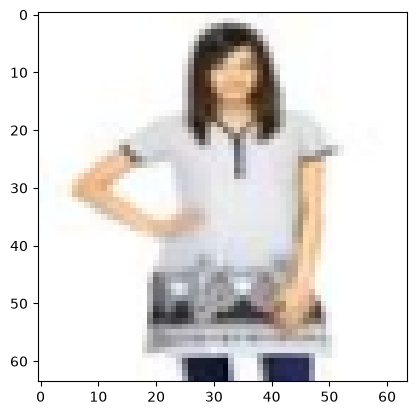

label:  [  0.       -23.185738 -32.952774 -24.007507 -50.473625]
label.shape:  (5,)
上身衣服


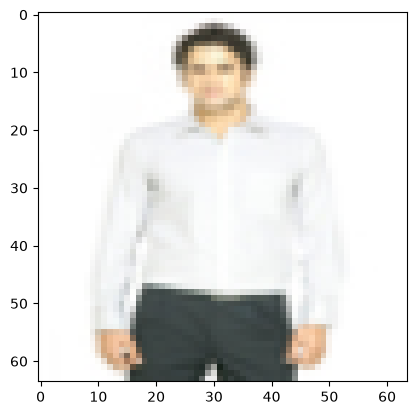

label:  [  0.       -17.13869  -32.62258  -26.139568 -35.738106]
label.shape:  (5,)
上身衣服


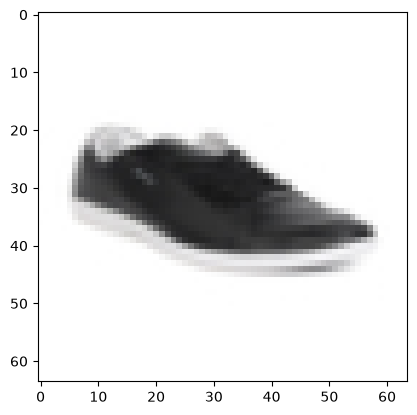

label:  [-40.452274   0.       -24.707783 -33.0005   -30.653976]
label.shape:  (5,)
鞋


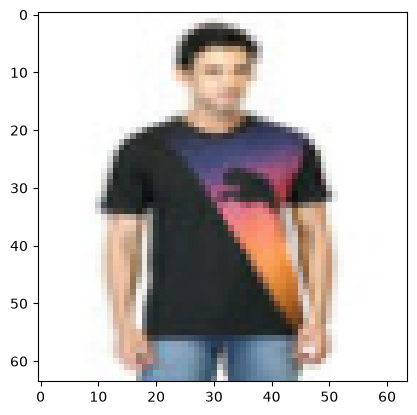

label:  [  0.       -18.35274  -32.073353 -35.167294 -31.725319]
label.shape:  (5,)
上身衣服


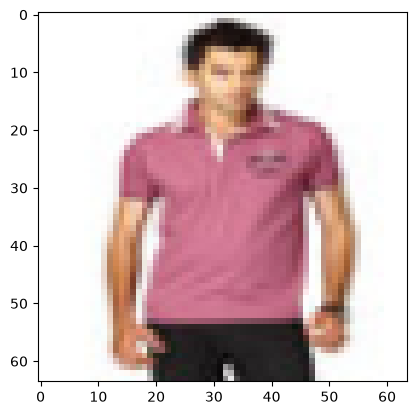

label:  [  0.       -44.60359  -49.068695 -55.33851  -64.600525]
label.shape:  (5,)
上身衣服


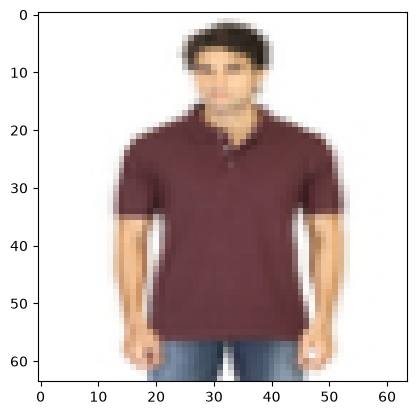

label:  [  0.       -29.724367 -37.22642  -32.87687  -41.404186]
label.shape:  (5,)
上身衣服


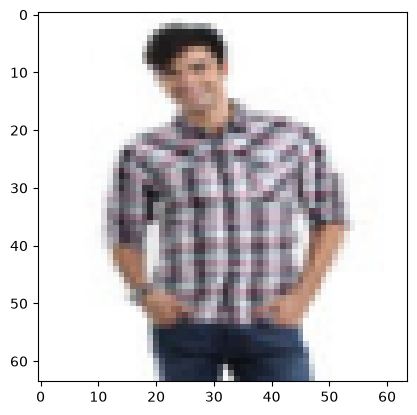

label:  [  0.       -33.060413 -42.3471   -25.46838  -22.723854]
label.shape:  (5,)
上身衣服


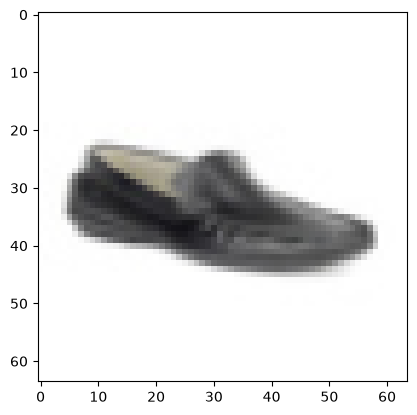

label:  [-37.434677   0.       -17.977137 -28.698828 -28.972786]
label.shape:  (5,)
鞋


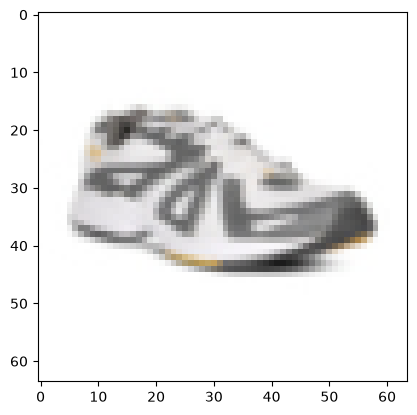

label:  [-34.9645     0.       -33.794926 -32.338036 -31.830612]
label.shape:  (5,)
鞋


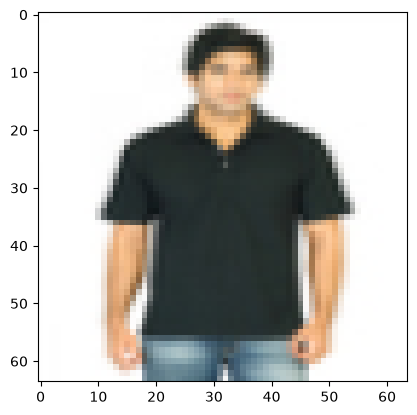

label:  [  0.       -25.306337 -37.24202  -36.83309  -38.947693]
label.shape:  (5,)
上身衣服


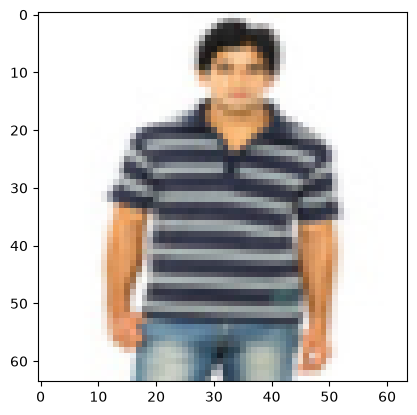

label:  [  0.       -30.839705 -28.063862 -51.154015 -34.936813]
label.shape:  (5,)
上身衣服


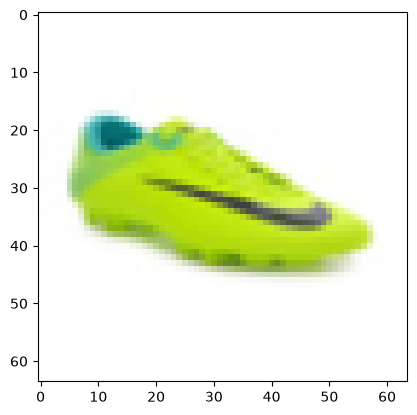

label:  [-31.495796   0.       -20.090084 -33.549915 -23.393272]
label.shape:  (5,)
鞋


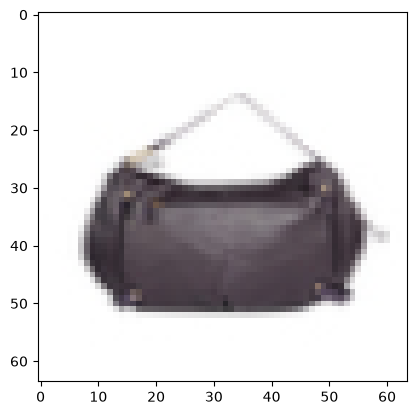

label:  [-34.516075 -25.884972   0.       -36.930275 -41.017605]
label.shape:  (5,)
包


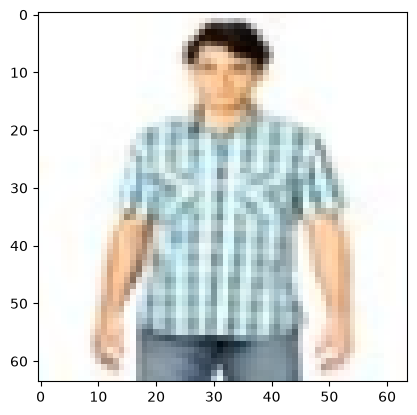

label:  [  0.       -34.70655  -47.927025 -30.745348 -46.039547]
label.shape:  (5,)
上身衣服


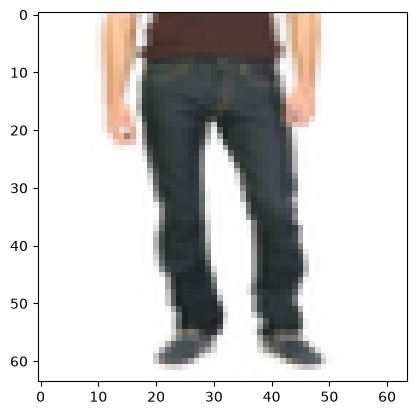

label:  [-31.251013 -37.542847 -54.714348   0.       -42.461266]
label.shape:  (5,)
下身衣服


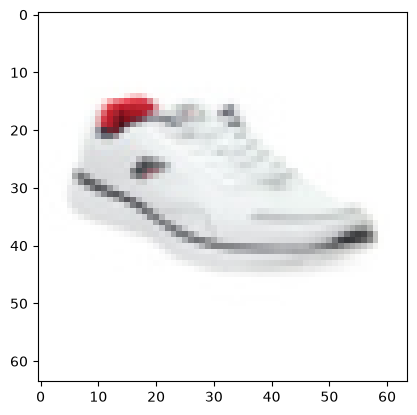

label:  [-19.502306   0.       -21.339714 -17.153578 -32.176865]
label.shape:  (5,)
鞋


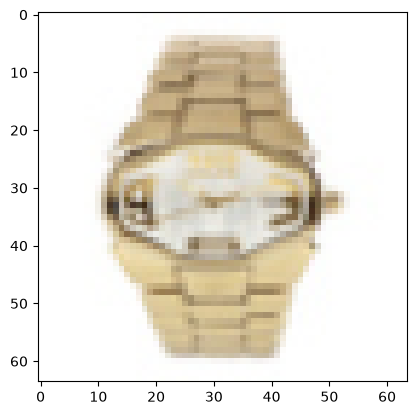

label:  [-23.634457 -34.17714  -18.619844 -23.70552    0.      ]
label.shape:  (5,)
手表


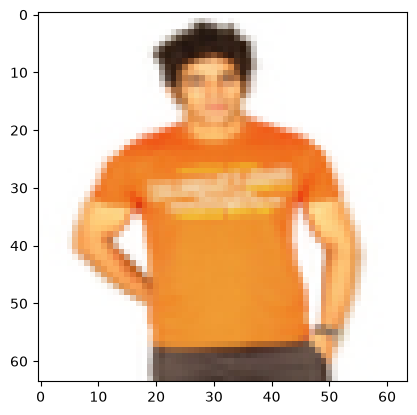

label:  [  0.       -23.434597 -40.567543 -33.763405 -34.658115]
label.shape:  (5,)
上身衣服


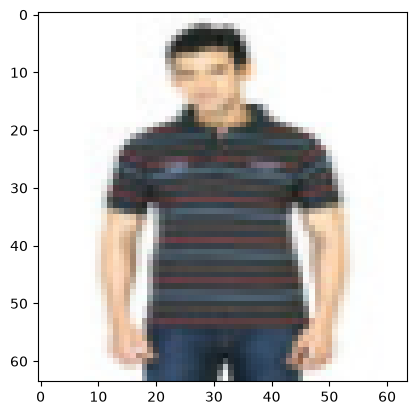

label:  [  0.       -24.451498 -37.876976 -34.26496  -34.79077 ]
label.shape:  (5,)
上身衣服


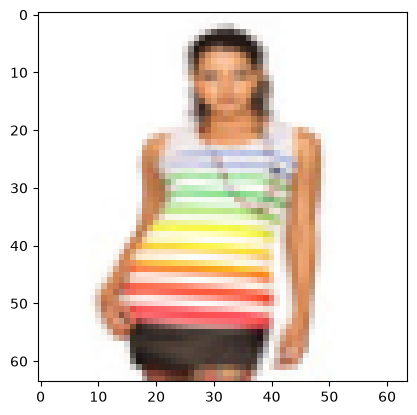

label:  [  0.       -33.751556 -23.737202 -39.702602 -25.126768]
label.shape:  (5,)
上身衣服


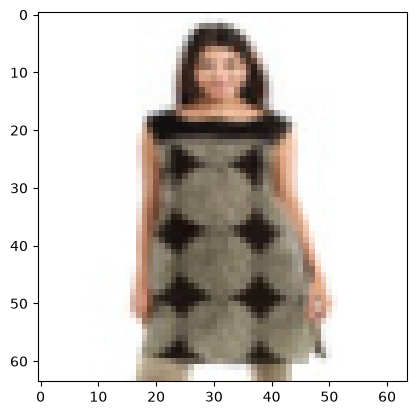

label:  [-2.3841831e-06 -2.5778990e+01 -2.2186136e+01 -1.2960863e+01
 -2.3297701e+01]
label.shape:  (5,)
上身衣服


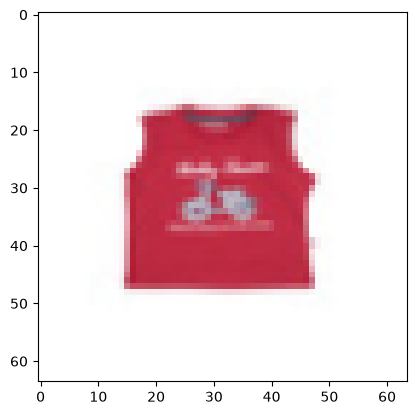

label:  [ -0.05619111 -13.36717     -2.9612954   -5.847858   -13.060803  ]
label.shape:  (5,)
上身衣服


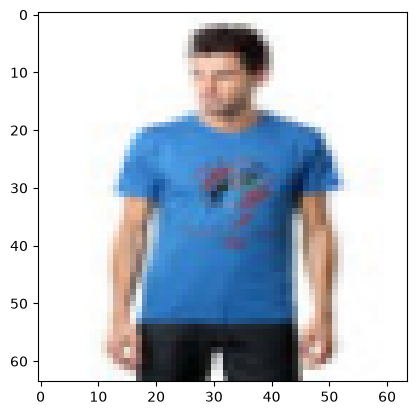

label:  [  0.       -48.31453  -46.826363 -37.99859  -48.340805]
label.shape:  (5,)
上身衣服


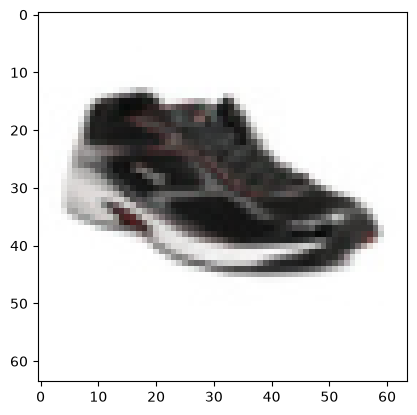

label:  [-50.940487   0.       -42.696716 -52.493843 -45.302734]
label.shape:  (5,)
鞋


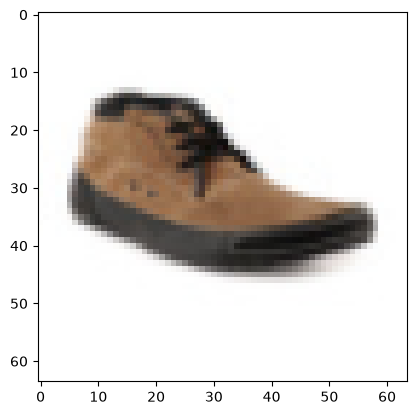

label:  [-42.11473    0.       -36.640526 -36.83577  -37.26613 ]
label.shape:  (5,)
鞋


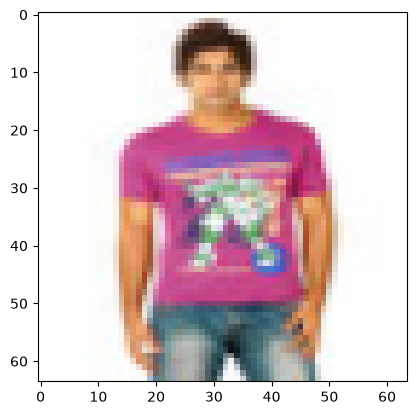

label:  [  0.       -27.853012 -25.456902 -29.962471 -25.42623 ]
label.shape:  (5,)
上身衣服


In [6]:
# 导入matplotlib库用于绘图
import matplotlib.pyplot as plt
# 在Jupyter Notebook中内嵌显示matplotlib图像
%matplotlib inline
# 导入numpy库用于数值计算
import numpy as np

# 获取验证集的一个批次数据
dataiter = iter(val_loader)
images, labels = next(dataiter)

# 将模型移动到CPU上，因为后续操作需要在CPU上执行
model.to('cpu')

# 获取模型对输入图像的输出结果
output = model(images)
# 将输出结果从计算图中分离，并转换为numpy数组
output = output.detach().numpy()
# 打印输出结果的形状
print(output.shape)

# 将输入图像从Tensor转换为numpy数组
images = images.numpy()
# 调整图像的维度顺序，从(C, H, W)变为(H, W, C)，以便matplotlib正确显示
images = np.moveaxis(images, 1, -1)
# 打印调整后的图像形状
print(images.shape)

# 遍历每个图像及其对应的模型输出结果
for img, label in zip(images, output):
    # 显示当前图像
    plt.imshow(img)
    plt.show()
    print("label: ", label)
    print("label.shape: ", label.shape)
    # 打印模型预测的类别名称
    print(classification_names[np.argmax(label)])